In [70]:
#importing basic libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.cm as cs
from warnings import filterwarnings


In [71]:
df=pd.read_csv('../data/DataCoSupplyChainDataset.csv',encoding='latin-1')

In [72]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [73]:
print('rows,cols', df.shape)
print('\ncoloumns:')
print(df.columns.tolist())
print('\nNum duplicates:',df.duplicated().sum())
print('\nMissing values(top 20):')
print(df.isna().sum().sort_values(ascending=False).head(20))

rows,cols (180519, 53)

coloumns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product

In [74]:
df['Benefit per order']==df['Order Profit Per Order']

0         True
1         True
2         True
3         True
4         True
          ... 
180514    True
180515    True
180516    True
180517    True
180518    True
Length: 180519, dtype: bool

In [75]:
(df['Benefit per order']==df['Order Profit Per Order']).value_counts()

True    180519
Name: count, dtype: int64

In [76]:
(df['Product Status']).value_counts()

Product Status
0    180519
Name: count, dtype: int64

In [77]:
#Data Cleaning
columns_to_drop=[
    'Product Description',
    'Order Zipcode',
    'Customer Lname',
    'Customer Zipcode',
    'Customer Fname',
    'Customer Email',
    'Customer Password',
    'Customer Street',
    'Order Profit Per Order', #same as Benifit Per order
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Product Category Id',
    'Product Status', #has only single value
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market'
]

In [78]:
len(df)

180519

In [79]:
#checking the current 
print('rows, cols:',df.shape)
print('\nMissing values(top 5):')
print(df.isna().sum().sort_values(ascending=False).head(5))

rows, cols: (180519, 53)

Missing values(top 5):
Product Description    180519
Order Zipcode          155679
Customer Lname              8
Customer Zipcode            3
Type                        0
dtype: int64


In [80]:
df.shape

(180519, 53)

In [81]:
#Filtering out the columns that have missing values, not important, or have only single value.
df=df.drop(columns=columns_to_drop)

#Filtering out the cancelled orders because they are not relevant for delivery time analysis.
df=df[df['Delivery Status']!='Shipping Canceled']

In [82]:
#Date conversion
for i in ['order date (DateOrders)','shipping date (DateOrders)']:
    df[i]=pd.to_datetime(df[i], errors='coerce',dayfirst=False)

In [83]:
#checking the overview again after the first bit of cleaning
print('rows, cols:',df.shape)
print('\nMissing values(top 5):')
print(df.isna().sum().sort_values(ascending=False).head(5))

rows, cols: (180519, 23)

Missing values(top 5):
Type                          0
Order Item Profit Ratio       0
shipping date (DateOrders)    0
Product Price                 0
Product Name                  0
dtype: int64


In [84]:
#No of values in category columns with low cardinality
for col in df.columns:
    if df[col].nunique()<10:
        print(f'\n{col} value counts:')
        print(df[col].value_counts())


Type value counts:
Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) value counts:
Days for shipping (real)
2    56618
3    28765
6    28723
4    28513
5    28163
0     5080
1     4657
Name: count, dtype: int64

Days for shipment (scheduled) value counts:
Days for shipment (scheduled)
4    107752
2     35216
1     27814
0      9737
Name: count, dtype: int64

Delivery Status value counts:
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

Late_delivery_risk value counts:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Customer Country value counts:
Customer Country
EE. UU.        111146
Puerto Rico     69373
Name: count, dtype: int64

Customer Segment value counts:
Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64

Order Item Quantity 

In [85]:
#Calculation of order processing time and delay
df['Order Processing Time']=(df['shipping date (DateOrders)']-df['order date (DateOrders)']).dt.days
df['Delay']=df['Order Processing Time']-df['Days for shipment (scheduled)']
df['Is_Delayed']=df['Delay']>0
df['Order Month']=df['order date (DateOrders)'].dt.month
df['Order_day']=df['order date (DateOrders)'].dt.day_name()
df['Order_hour']=df['order date (DateOrders)'].dt.hour

In [86]:
df.describe( )

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Product Price,shipping date (DateOrders),Order Processing Time,Delay,Order Month,Order_hour
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107609,0.548291,2016-06-12 17:47:04.669868,0.120647,2.127638,203.772096,183.107609,141.232550,2016-06-16 05:45:23.202433,3.471856,0.540010,6.235449,11.483689
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,1.000000,9.990000,7.490000,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,7.000000,104.379997,0.000000,2015-09-21 13:49:00,0.080000,1.000000,119.980003,104.379997,50.000000,2015-09-25 06:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,31.520000,163.990005,1.000000,2016-06-11 13:06:00,0.270000,1.000000,199.919998,163.990005,59.990002,2016-06-15 08:32:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,64.800003,247.399994,1.000000,2017-03-01 08:42:00,0.360000,3.000000,299.950012,247.399994,199.990005,2017-03-04 21:29:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,911.799988,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,5.000000,1999.989990,1939.989990,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623722,1.374449,104.433526,120.043670,0.497664,NaN,0.466796,1.453451,132.273077,120.043670,139.732492,NaN,1.670471,1.491881,3.403571,6.923006


In [87]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Name', 'Customer Country',
       'Customer Segment', 'Department Name', 'order date (DateOrders)',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Region', 'Order Status', 'Product Image',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order Processing Time', 'Delay', 'Is_Delayed',
       'Order Month', 'Order_day', 'Order_hour'],
      dtype='str')

In [88]:
#Profitability based on the Order profit per order
df['Profitability Flag'] = np.where(df['Benefit per order']>0,'Profit',np.where(df['Benefit per order']<0,'Loss','NIL'))
df['Profitability Flag'].value_counts()

Profitability Flag
Profit    145558
Loss       33784
NIL         1177
Name: count, dtype: int64

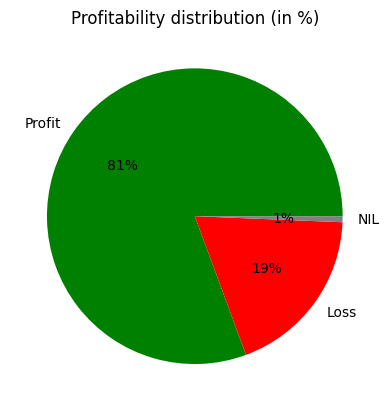

In [89]:
#Visualisation - Pie chart of profitability distribution
profit_percent= df['Profitability Flag'].value_counts(normalize=True)*100
profit_percent.plot(kind='pie', autopct='%1.f%%', colors=['green', 'red', 'grey'])
plt.ylabel('')
plt.title('Profitability distribution (in %)')
plt.show()

In [90]:
def format_func(value):
    if value >=1e6:
        return f'{value/1e6:.1f}M $'
    elif value >=1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'
    
delayed_df=df[df['Delay']>0]
metrics={}
metrics['Total Orders']=len(df)
metrics['Late Deliveries']=len(delayed_df)
metrics['(90% Delay (days)']=delayed_df['Delay'].quantile(0.90)
metrics['On time Delivery %']=float(metrics['Late Deliveries']/metrics['Total Orders'])*100
metrics['Total Profit']=format_func(df.loc[df['Benefit per order']>0,'Benefit per order'].sum())
metrics['Total Loss due to Delays']=format_func(df.loc[df['Delay']>0,'Benefit per order'].sum())

print('\n--- Business KPIs ---\n')
for k,v in metrics.items():
    if isinstance(v,float):
        print(f'{k}:{v:.2f}')
    else:
        print(f"{k}: {v}")


--- Business KPIs ---

Total Orders: 180519
Late Deliveries: 98743
(90% Delay (days):3.00
On time Delivery %:54.70
Total Profit: 7.9M $
Total Loss due to Delays: 2.1M $


### Profitability/Delivery Time Analysis

In [91]:
profit_metrics=(
    df.groupby('Delay')['Benefit per order']
        .agg(
            mean_profit='mean',
            total_profit='sum',
            order_count='count'
        )
        .reset_index()
)

In [92]:
profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2,23.423528,5.074942e+05,21666
1,-1,21.516997,4.669188e+05,21700
2,0,22.044854,8.467429e+05,38410
3,1,22.225592,1.244411e+06,55990
4,2,21.246239,6.101495e+05,28718
5,3,19.941130,1.406248e+05,7052
6,4,21.561202,1.505619e+05,6983


In [93]:
delay_distribution= (
    df['Delay']
    .value_counts(normalize=True)
    .sort_index()*100
).reset_index()

In [94]:
delay_distribution

,Delay,proportion
0,-2,12.002061
1,-1,12.020895
2,0,21.277539
3,1,31.016126
4,2,15.908575
5,3,3.906514
6,4,3.868291


In [95]:
import matplotlib.ticker as ticker


Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2,23.4,507494.2,21666
1,-1,21.5,466918.8,21700
2,0,22.0,846742.9,38410
3,1,22.2,1244410.9,55990
4,2,21.2,610149.5,28718
5,3,19.9,140624.8,7052
6,4,21.6,150561.9,6983


\Delay Distribution (%):


,Delay_days,Percentage
0,-2,12.002061
1,-1,12.020895
2,0,21.277539
3,1,31.016126
4,2,15.908575
5,3,3.906514
6,4,3.868291


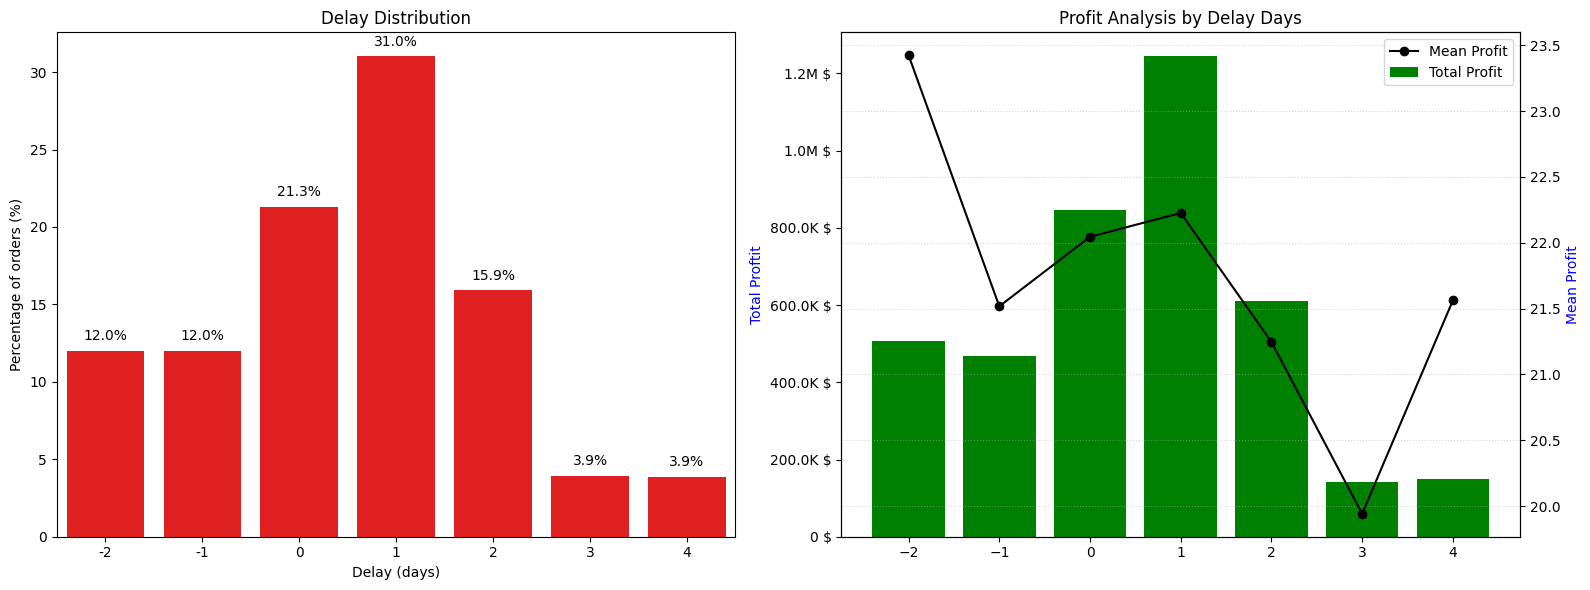

In [96]:
delay_distribution.columns=['Delay_days','Percentage']

print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("\Delay Distribution (%):")
display(delay_distribution)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,6))

# First subplot: Delay Distribution
sns.barplot(x='Delay_days',y='Percentage', data=delay_distribution, color='red', ax=ax1)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('Percentage of orders (%)')

#percentage text on bars
for bar in ax1.patches:
    height=bar.get_height()
    ax1.text(bar.get_x()+bar.get_width()/2, height+0.5,f'{height:.1f}%',ha='center',va='bottom')

#second subplot: Profit Analysis by Delay Days
ax2.set_ylabel('Total Proftit', color='blue')
ax2.bar(profit_metrics['Delay'],profit_metrics['total_profit'],color='green', label='Total Profit')
ax2.tick_params(axis='y',labelcolor='black')

ax3=ax2.twinx()

ax3.set_xlabel('Delay Days')
ax3.set_ylabel('Mean Profit',color='blue')
ax3.plot(profit_metrics['Delay'],profit_metrics['mean_profit'],marker='o',label='Mean Profit', color='black')
ax3.tick_params(axis='y', labelcolor='black')

#Format total profit axis to K $, M $
def format_func(value, tick_number):
    if value>=1e6:
        return f'{value/1e6:.1f}M $'
    elif value>=1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'
    
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

ax3.set_title("Profit Analysis by Delay Days")

lines, labels=ax3.get_legend_handles_labels()
lines2, labels2=ax2.get_legend_handles_labels()
ax3.legend(lines+lines2,labels+labels2, loc='upper right')
ax3.grid(True, linestyle=':',alpha=0.5)

plt.tight_layout()
plt.show()

## Bottleneck Detection

/var/folders/t5/ryj9t19x1f5ccfd8tw53kyth0000gn/T/ipykernel_81688/1511731069.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/t5/ryj9t19x1f5ccfd8tw53kyth0000gn/T/ipykernel_81688/1511731069.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/t5/ryj9t19x1f5ccfd8tw53kyth0000gn/T/ipykernel_81688/1511731069.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/t5/ryj9t19x1f5ccfd8tw53kyth0000gn/T/ipykernel_81688/1511731069.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

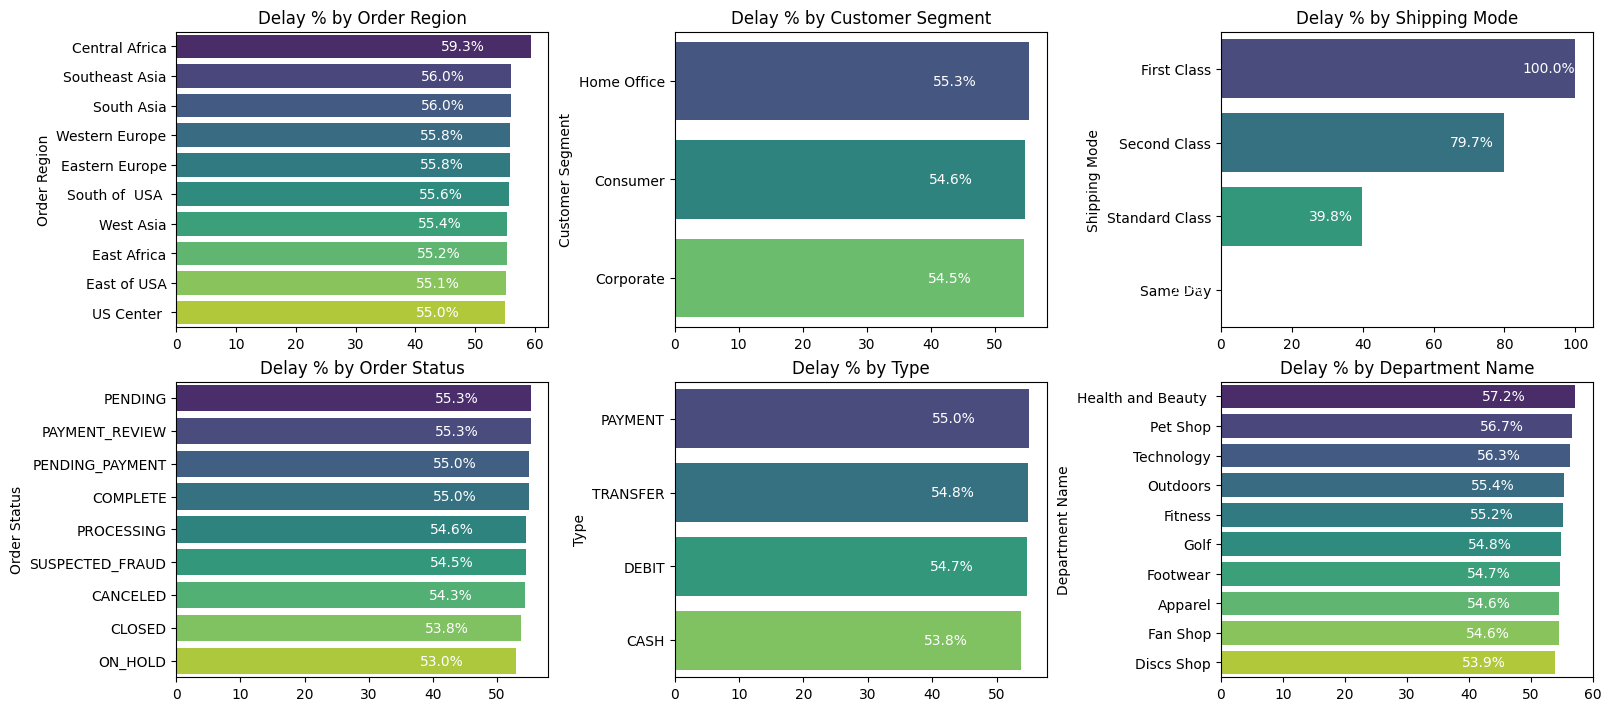

In [97]:
def compute_category_delay(cat):
    cat_df=df.groupby(cat).agg(
        total_orders=('Delay','count'),
        late_orders=('Is_Delayed','sum')
    ).reset_index()
    cat_df['delay_pct']=cat_df['late_orders']/cat_df['total_orders']*100
    cat_df=cat_df.sort_values('delay_pct', ascending=False).head(10)
    return cat_df

categories=['Order Region','Customer Segment','Shipping Mode','Order Status','Type','Department Name']

fig, axes=plt.subplots(2,3, figsize=(16,7), constrained_layout=True)
axes = axes.flatten()

for ax, category in zip(axes, categories):
    cat_df= compute_category_delay(category)
    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'
    )
    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)
    for i, row in cat_df.reset_index().iterrows():
        ax.text(row['delay_pct']-15, i, f"{row['delay_pct']:.1f}%", va='center', fontsize=10, color='white')

plt.show()


## Root cause Analysis

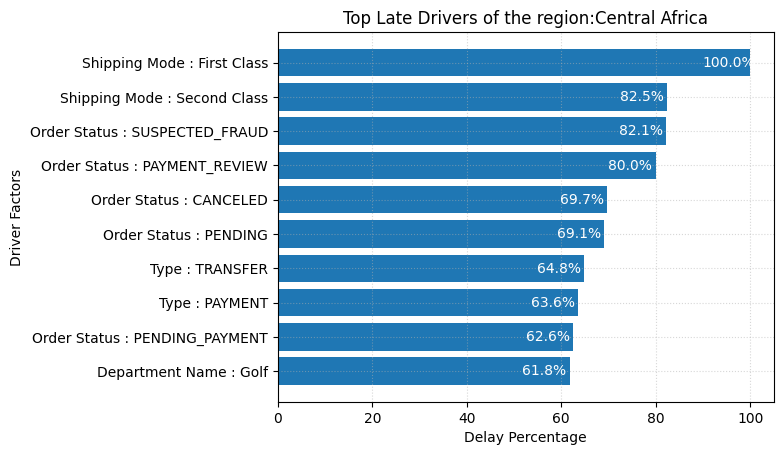

In [102]:
#Top Drivers for delivery by region

def top_drivers_region(region):
    df_region = df[df['Order Region']==region].copy()

    drivers=['Shipping Mode','Customer Segment','Department Name','Type','Order Status']

    all_factors=[]
    for factor in drivers:
        temp=(
            df_region.groupby(factor)
            .agg(
                total_orders=('Delay','count'),
                late_orders=('Is_Delayed','sum'),
                avg_delay=('Delay','mean')
            )
            .reset_index()
        )
        temp['delay_pct']=temp['late_orders']/temp['total_orders']*100
        temp['Driver']=factor
        temp['Factor_Level']=factor+" : "+temp[factor].astype(str)

        all_factors.append(temp[['Driver','Factor_Level','delay_pct','avg_delay','total_orders']])

    #Combine all drivers
    final_df=pd.concat(all_factors)

    #Top 10 drivers
    top_factors=final_df.sort_values('delay_pct',ascending=False).head(10)
    plt.figure()

    bars=plt.barh(top_factors['Factor_Level'],top_factors['delay_pct'])

    plt.xlabel("Delay Percentage")
    plt.ylabel("Driver Factors")
    plt.title(f"Top Late Drivers of the region:{region}")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().invert_yaxis()
    for bar in bars:
        width=bar.get_width()
        plt.text(width-10,bar.get_y()+bar.get_height()/2,
            f"{width:.1f}%",
            va='center',fontsize=10, color='white')
    
    plt.show()
top_drivers_region('Central Africa')

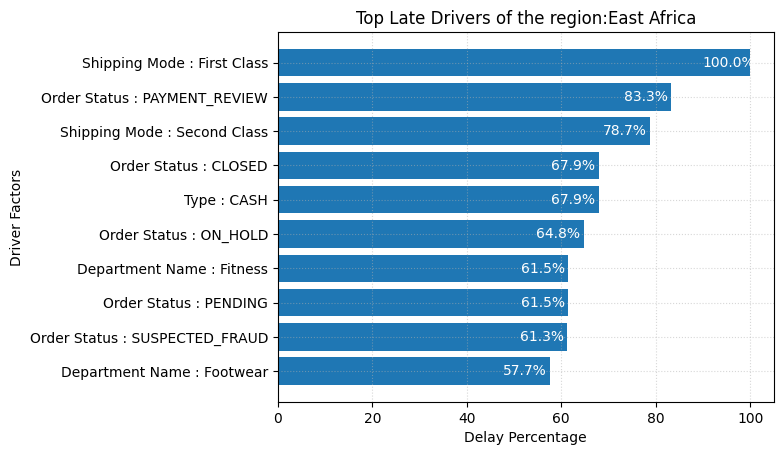

In [103]:
top_drivers_region('East Africa')